# Weight Uncertainty for Classification

This notebook illustrates IVON's weight uncertainty on a simple classification task.

In [1]:
import torch
import matplotlib.pyplot as plt

from evon import EVON
from ivon import IVON
from sklearn.datasets import make_moons


plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
        'axes.labelsize': 8,
        'font.size': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray',
        'xtick.major.size': 2,
        'xtick.major.width': 0.5,
        'ytick.major.size': 2,
        'ytick.major.width': 0.5,
        'xtick.minor.size': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.size': 1,
        'ytick.minor.width': 0.5,
    }
)

%config InlineBackend.figure_format = "svg"

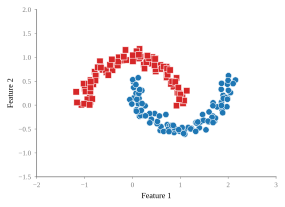

In [2]:
def plot_data(ax, X, y):
    for cls, m, c in [(0, 's', 'tab:red'), (1, 'o', 'tab:blue')]:
        ax.scatter(
            *X[y == cls].T,
            marker=m,
            color=c,
            s=40,
            edgecolors='white',
            linewidths=0.5,
            label=cls,
        )


fig, ax = plt.subplots(figsize=(5 / 1.2, 3.5 / 1.2))

torch.manual_seed(2)

X, y = make_moons(n_samples=200, noise=0.08)
X = torch.as_tensor(X, dtype=torch.float32)
y = torch.as_tensor(y, dtype=torch.float32)
plot_data(ax, X, y)

ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-2, 3), ylim=(-1.5, 2))
ax.set_aspect('equal')
plt.tight_layout()

In [3]:
class MLP(torch.nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        layers = [torch.nn.Linear(2, hidden), torch.nn.ReLU()]
        for _ in range(3):
            layers += [torch.nn.Linear(hidden, hidden), torch.nn.ReLU()]
        layers += [torch.nn.Linear(hidden, 1)]
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP()

opt = IVON(
    model.parameters(),
    lr=0.05,
    ess=1e2,
    weight_decay=1e-5,
    hess_init=0.001,
    beta1=0.9, 
    beta2=0.9995,
    clip_radius=0.5,
    rescale_lr=False
)

steps = 7500
loss_fn = torch.nn.BCEWithLogitsLoss()
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, eta_min=0.0, T_max=steps)

for _ in range(steps + 1):
    with opt.sampled_params(train=True):
        opt.zero_grad()
        loss = loss_fn(model(X), y.view(-1, 1))
        loss.backward()
    opt.step()
    sched.step()

Next, we train the same network with EVON. It runs IVON in the eigenspace of the SOAP preconditioner, so its posterior covariance in weight space is not restricted to be diagonal and can capture correlations between the network's weights.

In [4]:
model_evon = MLP()

opt_evon = EVON(
    model_evon.parameters(),
    lr=0.2,
    ess=1e2,
    weight_decay=1e-5,
    hess_init=0.001,
    betas=(0.9, 0.9995),
    mc_samples=1,
    precondition_frequency=10,
    whiten_prec_grad=True,
)

sched_evon = torch.optim.lr_scheduler.CosineAnnealingLR(opt_evon, eta_min=0.0, T_max=steps)

for _ in range(steps + 1):
    with opt_evon.sampled_params(train=True):
        opt_evon.zero_grad()
        loss = loss_fn(model_evon(X), y.view(-1, 1))
        loss.backward()
    opt_evon.step()
    sched_evon.step()


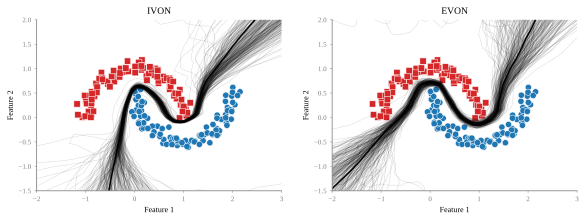

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10 / 1.2, 3.5 / 1.2))

xx, yy = torch.meshgrid(*[torch.linspace(*lim, 200) for lim in [(-2, 3), (-1.5, 2)]], indexing='xy')
grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)

for ax, opt_i, model_i, title in [(axs[0], opt, model, 'IVON'), (axs[1], opt_evon, model_evon, 'EVON')]:
    plot_data(ax, X, y)
    ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-2, 3), ylim=(-1.5, 2), title=title)

    with torch.no_grad():
        for _ in range(250):
            with opt_i.sampled_params(train=False):
                zz = model_i(grid).reshape(xx.shape)
            ax.contour(xx, yy, zz, levels=[0], colors='k', alpha=0.15, linewidths=0.5)

        zz = model_i(grid).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=[0], colors='k', linewidths=1.5)

    ax.set_aspect('equal')

plt.tight_layout()
